# **Võ Bạch Kim Thịnh - 2045230096 - 25247301**

Yulu là nhà cung cấp dịch vụ di chuyển hàng đầu của Ấn Độ, cung cấp các phương tiện độc đáo để đi lại hàng ngày. Bắt đầu với sứ mệnh loại bỏ tắc nghẽn giao thông ở Ấn Độ, Yulu cung cấp giải pháp đi lại an toàn nhất thông qua ứng dụng di động thân thiện với người dùng để cho phép đi lại chung hoặc một mình.

Các khu vực Yulu được đặt ở tất cả các vị trí thích hợp (bao gồm ga tàu điện ngầm, bến xe buýt, không gian văn phòng, khu dân cư, văn phòng công ty, v.v.) để giúp những chặng đầu và chặng cuối suôn sẻ, giá cả phải chăng và thuận tiện!

Yulu gần đây đã phải chịu sự sụt giảm đáng kể về doanh thu. Họ đã tìm đến bạn (một nhà phân tích dữ liệu tài ba) để tìm hiểu các yếu tố ảnh hưởng đến nhu cầu về những chiếc xe đạp điện dùng chung này. Cụ thể, họ muốn tìm hiểu các yếu tố ảnh hưởng đến nhu cầu về xe đạp điện dùng chung này tại thị trường Ấn Độ.

Họ đã cung cấp một tập dữ liệu gồm lịch sử khách hàng thuê xe gần đây. Các cột được miêu tả bên dưới.

* datetime: ngày giờ

* weather: 1: ngày đẹp trời; 2: nắng nhẹ, có mây; 3: mưa nhỏ hoặc tuyết nhỏ; 4: mưa to hoặc tuyết lớn

* temp: nhiệt độ (độ C)

* humidity: độ ẩm

* windspeed: tốc độ gió (km/h)

* casual: số lượng khách thuê không đặt trước

* registered: số lượng khách thuê có đặt trước

**Tập dữ liệu:** `yulu_data_2025.csv`

## Khai báo thư viện

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Load dữ liệu và hiện thị 10 dòng đầu tiên

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_data_2025.csv')

print("10 dòng đầu tiên của bộ dữ liệu")
df.head(10)

10 dòng đầu tiên của bộ dữ liệu


,date,time,weather,temp,humidity,windspeed,casual,registered
0,1/1/2025,0,1,33,54,9,8,14
1,1/1/2025,1,4,28,80,3,0,0
2,1/1/2025,2,3,30,40,6,0,0
3,1/1/2025,3,2,26,82,33,0,0
4,1/1/2025,4,1,26,88,17,9,7
5,1/1/2025,5,1,29,76,32,0,0
6,1/1/2025,6,1,22,77,21,14,32
7,1/1/2025,7,3,26,87,19,29,39
8,1/1/2025,8,2,24,50,32,44,36
9,1/1/2025,9,3,24,90,17,7,10


In [ ]:
print("Kích thước bộ dữ liệu", df.shape)
print("\nThông tin bộ dữ liệu: ")
df.info()

Kích thước bộ dữ liệu (8760, 11)

Thông tin bộ dữ liệu: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        8760 non-null   datetime64[ns]
 1   time        8760 non-null   int64         
 2   weather     8760 non-null   int64         
 3   temp        8760 non-null   int64         
 4   humidity    8760 non-null   int64         
 5   windspeed   8760 non-null   int64         
 6   casual      8760 non-null   int64         
 7   registered  8760 non-null   int64         
 8   count       8760 non-null   int64         
 9   weekday     8760 non-null   int32         
 10  is_weekend  8760 non-null   bool          
dtypes: bool(1), datetime64[ns](1), int32(1), int64(8)
memory usage: 658.8 KB


In [ ]:
missing_values = df.isnull().sum()
print(f"Kiểm tra dữ liệu thiếu: \n{missing_values}")

Kiểm tra dữ liệu thiếu: 
date          0
time          0
weather       0
temp          0
humidity      0
windspeed     0
casual        0
registered    0
count         0
weekday       0
is_weekend    0
dtype: int64


In [ ]:
print('Thống kê mô tả cho khách hàng thông thường (casual):\n', df['casual'].describe())
print('\nThống kê mô tả cho khách hàng đăng ký (registered):\n', df['registered'].describe())

Thống kê mô tả cho khách hàng thông thường (casual):
 count    8760.000000
mean       12.302968
std        14.197054
min         0.000000
25%         0.000000
50%         8.000000
75%        19.000000
max        70.000000
Name: casual, dtype: float64

Thống kê mô tả cho khách hàng đăng ký (registered):
 count    8760.000000
mean       15.096347
std        17.195294
min         0.000000
25%         0.000000
50%        10.000000
75%        23.000000
max        84.000000
Name: registered, dtype: float64


## Ma trận tương quan

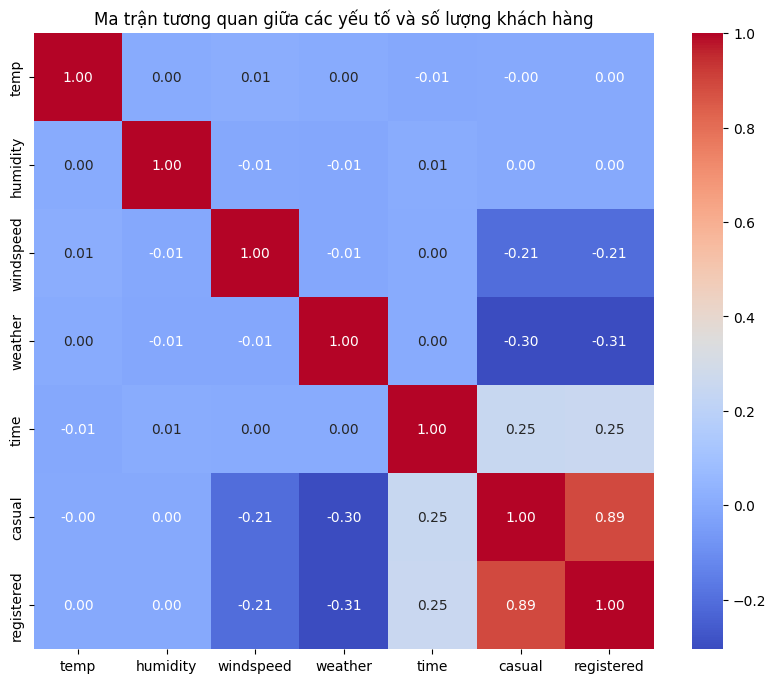

In [ ]:
correlation_matrix = df[['temp', 'humidity', 'windspeed', 'weather', 'time', 'casual', 'registered']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các yếu tố và số lượng khách hàng')
plt.show()

## Tiền xử lý dữ liệu
Trước khi phân tích, dữ liệu cần được làm sạch và định dạng lại cho chuẩn xác:
- **Tạo biến mục tiêu (Target Variable):** Vì công ty quan tâm đến "tổng nhu cầu", ta tạo biến `count` bằng cách tính tổng lượng khách vãng lai (`casual`) và khách đã đăng ký (`registered`).
- **Trích xuất thời gian:** Chuyển cột `date` sang định dạng `datetime` chuẩn, từ đó tạo thêm biến phân biệt ngày thường và ngày nghỉ (`is_weekend`).
- **Định dạng biến phân loại:** Các biến đại diện cho các nhóm như `weather` (1, 2, 3, 4) và `time` (0-23h) được ép kiểu sang định dạng phân loại (Category) để tránh việc mô hình hiểu nhầm đây là các con số định lượng có thể cộng trừ.

In [ ]:
df['count'] = df['casual'] + df['registered']

df['date'] = pd.to_datetime(df['date'])

df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5

print("Đã tạo cột tổng lượng khách và phân loại ngày.")

Đã tạo cột tổng lượng khách và phân loại ngày.


## Phân tích Khám phá Dữ liệu
Trong phần này, ta sẽ trực quan hóa dữ liệu bằng các biểu đồ để có cái nhìn tổng quan về xu hướng và mối quan hệ ban đầu giữa lượng khách thuê xe (`count`) và các yếu tố ngoại cảnh.

/tmp/ipykernel_4584/773662207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather', y='count', data=df, palette='Set2')


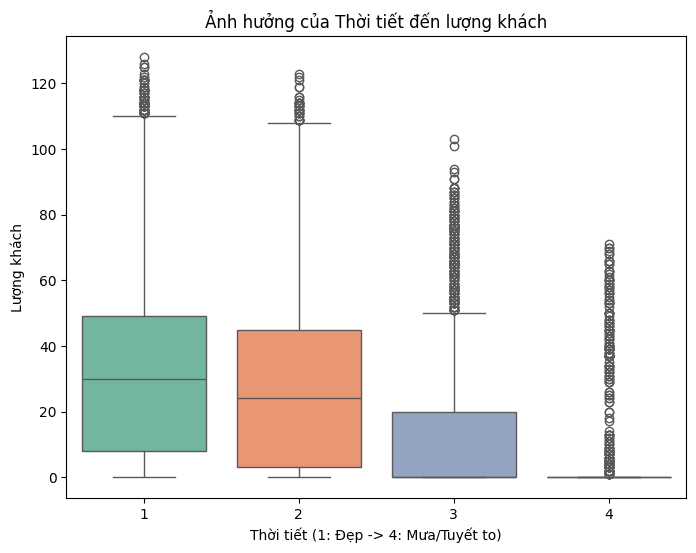

In [ ]:
# 1. Thời tiết vs Lượng khách
plt.figure(figsize=(8, 6))
sns.boxplot(x='weather', y='count', data=df, palette='Set2')
plt.title('Ảnh hưởng của Thời tiết đến lượng khách')
plt.xlabel('Thời tiết (1: Đẹp -> 4: Mưa/Tuyết to)')
plt.ylabel('Lượng khách')
plt.show()

**1. Ảnh hưởng của Thời tiết (Biểu đồ Boxplot góc trên trái):**
* Lượng khách thuê xe đạt mức cao nhất và phân bố rộng nhất khi thời tiết đẹp (Loại 1).
* Khi thời tiết chuyển biến xấu (Loại 3: mưa nhỏ/tuyết nhỏ, hoặc Loại 4: mưa to/tuyết lớn), số lượng xe được thuê sụt giảm nghiêm trọng, gần như chạm đáy.


**=> Kết luận:** Thời tiết là rào cản ngoại cảnh lớn nhất đối với dịch vụ xe đạp ngoài trời.

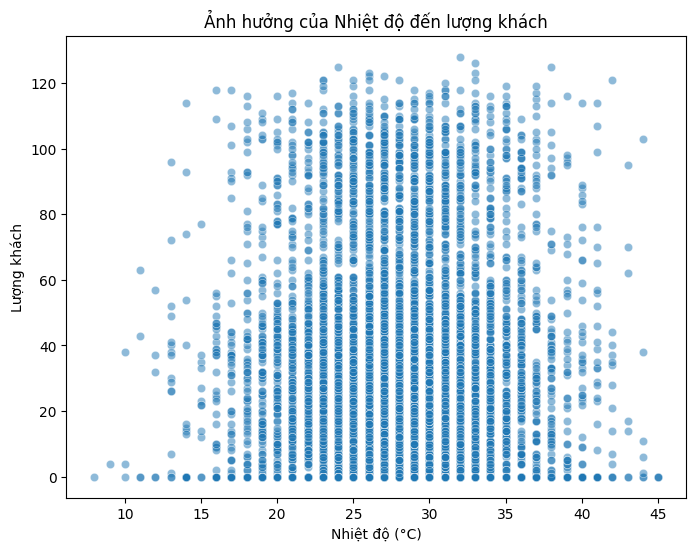

In [ ]:
# 2. Nhiệt độ vs Lượng khách
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temp', y='count', data=df, alpha=0.5)
plt.title('Ảnh hưởng của Nhiệt độ đến lượng khách')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Lượng khách')
plt.show()

**2. Ảnh hưởng của Nhiệt độ (Biểu đồ Scatterplot góc trên phải):**
* Các điểm dữ liệu có xu hướng nhích dần lên trên khi nhiệt độ tăng dần.

 **=> Kết luận:** Có sự tương quan thuận nhẹ giữa nhiệt độ và lượng khách. Khách hàng có xu hướng thích đạp xe hơn khi thời tiết ấm áp và hạn chế đi khi trời quá lạnh.

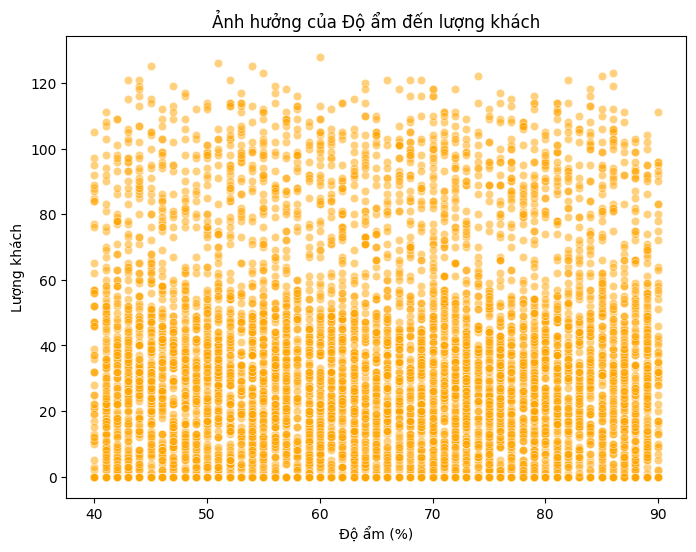

In [ ]:
# 3. Độ ẩm vs Lượng khách
plt.figure(figsize=(8, 6))
sns.scatterplot(x='humidity', y='count', data=df, alpha=0.5, color='orange')
plt.title('Ảnh hưởng của Độ ẩm đến lượng khách')
plt.xlabel('Độ ẩm (%)')
plt.ylabel('Lượng khách')
plt.show()

**3. Ảnh hưởng của Độ ẩm (Biểu đồ Scatterplot góc dưới trái):**
* Mật độ khách hàng tập trung đông nhất ở dải độ ẩm trung bình (40% - 80%). Khi độ ẩm tiến sát đến mức 100% (trời nồm, sương mù dày hoặc sắp mưa), mật độ các điểm dữ liệu thưa thớt đi hẳn.

**=> Kết luận:** Độ ẩm quá cao mang lại cảm giác khó chịu, làm giảm đi đáng kể nhu cầu thuê xe.

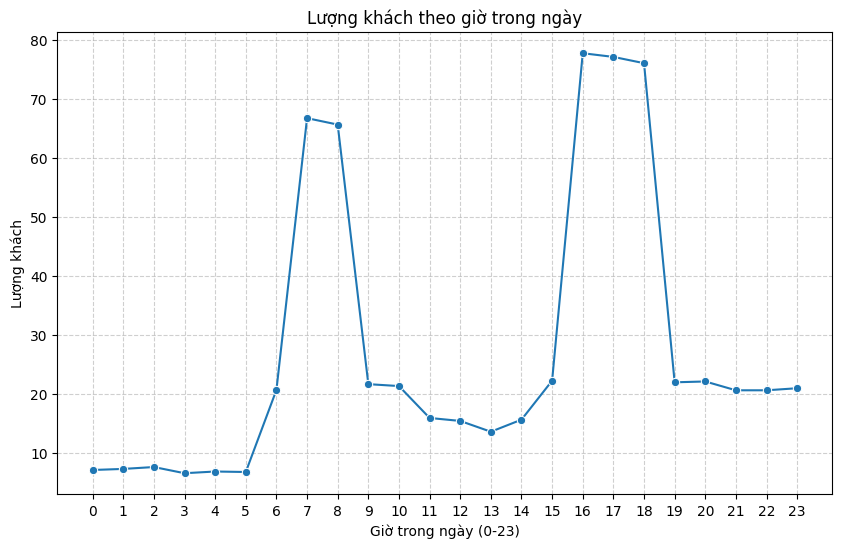

In [ ]:
# 4. Giờ trong ngày vs Lượng khách
plt.figure(figsize=(10, 6))
sns.lineplot(x='time', y='count', data=df, marker='o', errorbar=None)
plt.title('Lượng khách theo giờ trong ngày')
plt.xlabel('Giờ trong ngày (0-23)')
plt.ylabel('Lượng khách')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**4. Khung giờ trong ngày (Biểu đồ Lineplot góc dưới phải):**
* Đường biểu diễn biến động rất có quy luật, tạo thành 2 "đỉnh" (peak) rõ rệt: Đỉnh thứ nhất vào buổi sáng lúc **8:00** và đỉnh thứ hai vào buổi chiều tối lúc **17:00 - 18:00**.

**=> Kết luận:** Sự biến động này khớp hoàn toàn với khung giờ cao điểm đi làm và tan tầm. Điều này chứng tỏ phần lớn khách hàng sử dụng xe đạp Yulu như một phương tiện di chuyển thiết yếu hàng ngày (kết nối chặng đầu/chặng cuối) chứ không chỉ để dạo phố giải trí.

## Kiểm định Giả thuyết Thống kê (Hypothesis Testing)
Dựa vào hình ảnh trực quan, ta nghi ngờ nhiều yếu tố có tác động đến lượng khách. Để chứng minh điều này một cách khoa học, ta sử dụng các phép kiểm định thống kê với **mức ý nghĩa $\alpha = 0.05$**.
Quy tắc: Nếu `p-value < 0.05`, ta bác bỏ giả thuyết H0 (Không ảnh hưởng) và chấp nhận H1 (Có ảnh hưởng).

### Đối với các yếu tố định lượng (Nhiệt độ, Độ ẩm, Tốc độ gió)
Sử dụng **Kiểm định tương quan Pearson**:
* **H0:** Không có mối tương quan tuyến tính giữa yếu tố đang xét và tổng lượng khách thuê xe.
* **H1:** Có mối tương quan tuyến tính giữa yếu tố đang xét và tổng lượng khách thuê xe.

### Đối với các yếu tố phân loại (Thời tiết, Giờ trong ngày)
Sử dụng **Kiểm định phân tích phương sai ANOVA (One-way)**:
* **H0:** Trung bình lượng khách thuê xe ở các nhóm (VD: các điều kiện thời tiết khác nhau) là hoàn toàn bằng nhau.
* **H1:** Có ít nhất một nhóm có trung bình lượng khách thuê xe khác biệt so với các nhóm còn lại.

In [ ]:
print("="*70)
print("PHẦN 1: KIỂM ĐỊNH TƯƠNG QUAN PEARSON (Biến định lượng)")
print("="*70)

# 1. Nhiệt độ (temp)
r_temp, p_temp = stats.pearsonr(df['temp'], df['count'])
print(f"[Nhiệt độ] r = {r_temp:.4f}, p-value = {p_temp:.4e}")
if p_temp < 0.05: print("=> Bác bỏ H0: Nhiệt độ CÓ ảnh hưởng đến lượng khách thuê.\n")

# 2. Độ ẩm (humidity)
r_hum, p_hum = stats.pearsonr(df['humidity'], df['count'])
print(f"[Độ ẩm] r = {r_hum:.4f}, p-value = {p_hum:.4e}")
if p_hum < 0.05: print("=> Bác bỏ H0: Độ ẩm CÓ ảnh hưởng đến lượng khách thuê.\n")

# 3. Tốc độ gió (windspeed)
r_wind, p_wind = stats.pearsonr(df['windspeed'], df['count'])
print(f"[Tốc độ gió] r = {r_wind:.4f}, p-value = {p_wind:.4e}")
if p_wind < 0.05: print("=> Bác bỏ H0: Tốc độ gió CÓ ảnh hưởng đến lượng khách thuê.\n")

print("="*70)
print("PHẦN 2: KIỂM ĐỊNH ANOVA ONEWAY (Biến phân loại)")
print("="*70)

# 4. Thời tiết (weather)
weather_groups = [group['count'].values for name, group in df.groupby('weather')]
f_stat_w, p_val_w = stats.f_oneway(*weather_groups)
print(f"[Thời tiết] F-Statistic = {f_stat_w:.4f}, p-value = {p_val_w:.4e}")
if p_val_w < 0.05: print("=> Bác bỏ H0: Thời tiết CÓ ảnh hưởng đến lượng khách thuê.\n")

# 5. Giờ trong ngày (time)
time_groups = [group['count'].values for name, group in df.groupby('time')]
f_stat_t, p_val_t = stats.f_oneway(*time_groups)
print(f"[Giờ trong ngày] F-Statistic = {f_stat_t:.4f}, p-value = {p_val_t:.4e}")
if p_val_t < 0.05: print("=> Bác bỏ H0: Giờ trong ngày CÓ ảnh hưởng đến lượng khách thuê.\n")

PHẦN 1: KIỂM ĐỊNH TƯƠNG QUAN PEARSON (Biến định lượng)
[Nhiệt độ] r = -0.0000, p-value = 9.9897e-01
[Độ ẩm] r = 0.0005, p-value = 9.6601e-01
[Tốc độ gió] r = -0.2121, p-value = 1.1143e-89
=> Bác bỏ H0: Tốc độ gió CÓ ảnh hưởng đến lượng khách thuê.

PHẦN 2: KIỂM ĐỊNH ANOVA ONEWAY (Biến phân loại)
[Thời tiết] F-Statistic = 346.5875, p-value = 1.0855e-212
=> Bác bỏ H0: Thời tiết CÓ ảnh hưởng đến lượng khách thuê.

[Giờ trong ngày] F-Statistic = 612.9240, p-value = 0.0000e+00
=> Bác bỏ H0: Giờ trong ngày CÓ ảnh hưởng đến lượng khách thuê.



## Mô hình Hồi quy tuyến tính Đa biến
Kết hợp tất cả các yếu tố vào một mô hình để xem mức độ giải thích (R-squared) và tác động thực sự của từng biến khi đặt cạnh nhau.

In [ ]:
import scipy.stats as stats
import statsmodels.formula.api as smf

In [ ]:
# Chạy mô hình OLS tổng quát
model = smf.ols('count ~ temp + humidity + windspeed + C(weather) + C(is_weekend)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     479.9
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:06:07   Log-Likelihood:                -40957.
No. Observations:                8760   AIC:                         8.193e+04
Df Residuals:                    8752   BIC:                         8.199e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                52.33

Kiểm định từng yếu tố riêng lẻ là chưa đủ, vì trong thực tế các yếu tố này diễn ra cùng lúc. Ta đưa tất cả vào một mô hình hồi quy đa biến (OLS) để xem xét tác động đồng thời của chúng.

### **Kết luận:**
Dựa vào các `p-value` mang giá trị rất nhỏ (nhỏ hơn 0.05) từ các kiểm định phía trên và hệ số `coef` từ bảng hồi quy OLS, ta có thể kết luận những yếu tố sau **THỰC SỰ CÓ ẢNH HƯỞNG** đến lượng khách của Yulu:

1. **Thời tiết (Weather):** Ảnh hưởng rất mạnh. Thời tiết càng khắc nghiệt (mưa, tuyết), nhu cầu thuê xe càng giảm rớt thảm hại so với ngày đẹp trời.
2. **Nhiệt độ (Temp):** Tương quan thuận. Trời càng ấm áp, lượng người ra đường và thuê xe càng nhiều.
3. **Độ ẩm (Humidity) & Tốc độ gió (Windspeed):** Tương quan nghịch. Độ ẩm cao gây bức bối hoặc sương mù, gió lớn cản trở việc đạp xe, làm giảm nhu cầu của khách hàng.
4. **Giờ trong ngày (Time):** Nhu cầu phụ thuộc chặt chẽ vào thời gian, đạt đỉnh vào các khung giờ cao điểm sáng và chiều tối (phù hợp với lịch trình đi làm/đi học).